In [ ]:
from src.ch6.olg_deterministic.olg import search_equilibrium
from src.ch6.olg_deterministic.setting import Setting
from utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
baseline = search_equilibrium(
    Setting(),
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)

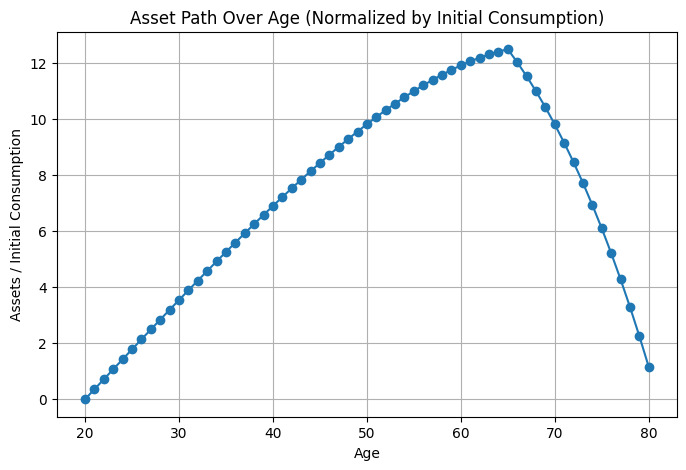

In [3]:
# 初期消費で正規化したプロット
c1_baseline = baseline.equilibrium.c_path[0]  # 初期消費

# 年齢軸（20歳から）
age_axis = np.arange(20, 20 + len(baseline.equilibrium.aprime_path))

# 資産パスをプロット（初期消費で正規化）
plt.figure(figsize=(8, 5))
plt.plot(age_axis, baseline.equilibrium.aprime_path / c1_baseline, marker='o')
plt.title('Asset Path Over Age (Normalized by Initial Consumption)')
plt.xlabel('Age')
plt.ylabel('Assets / Initial Consumption')
plt.grid()
plt.show()

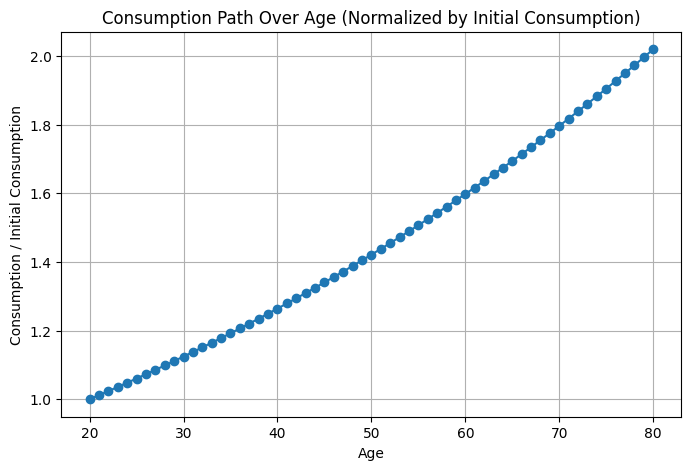

In [4]:
# 消費パスをプロット（初期消費で正規化）
plt.figure(figsize=(8, 5))
plt.plot(age_axis, baseline.equilibrium.c_path / c1_baseline, marker='o')
plt.title('Consumption Path Over Age (Normalized by Initial Consumption)')
plt.xlabel('Age')
plt.ylabel('Consumption / Initial Consumption')
plt.grid()
plt.show()

In [5]:
baseline.equilibrium.r_star
baseline.equilibrium.K_star

6.116620227285432

In [6]:
# シナリオごとに解く
# 所得代替率の半減
low_replacement_rate = search_equilibrium(
    Setting(psi=0.25),
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)
# 定年引き上げ（労働が50期間, 年金受給者/総人口が減少、労働者/総人口が増加）
retire_at_71 = search_equilibrium(
    Setting(jr=51), #引退期の開始が51歳
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)
# 高齢化（年金受給者/総人口が増加、労働者/総人口が減少, 総人口が増加）
live_to_85 = search_equilibrium(
    Setting(J =66, mu = (np.ones(66)/61)), # 20〜85 歳 → 66 期、NjW（労働機関）はベースラインのまま（45 期）
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)
work_until_death = search_equilibrium( # 生涯現役、死ぬまで働く
    Setting(jr = 62),
    Kd0 = 500,
    lambdaR = 0.01,
    DEBUG_MODE=False
)


scenarios = {
    "baseline": baseline,
    "low_replacement_rate": low_replacement_rate,
    "retire_at_71": retire_at_71,
    "live_to_85": live_to_85,
    "work_until_death": work_until_death
}

In [7]:
rows = []
for key, result in scenarios.items():
    rows.append({
            "Scenario": key,
            'K': 100*(result.equilibrium.K_star - baseline.equilibrium.K_star)/baseline.equilibrium.K_star,
            'K/L': 100*(result.equilibrium.K_star/result.equilibrium.L_star - baseline.equilibrium.K_star/baseline.equilibrium.L_star)/baseline.equilibrium.K_star*baseline.equilibrium.L_star,
            'r': 100*(result.equilibrium.r_star),
            'w': 100*(result.equilibrium.w_star - baseline.equilibrium.w_star)/baseline.equilibrium.w_star,
            'tau': 100*result.equilibrium.tau,
            'ss_toal': result.equilibrium.p * (result.setting.J - result.setting.jr + 1)
    })
df = pd.DataFrame(rows)
for col in ['K','K/L', 'w']:
    df[col] = df[col].apply(lambda x: f"{x:+.1f}%")
for col in ['r', 'tau']:
    df[col] = df[col].apply(lambda x: f"{x:.1f}%")
print(df)

               Scenario       K     K/L     r      w    tau    ss_toal
0              baseline   +0.0%   +0.0%  3.2%  +0.0%  17.8%  11.186470
1  low_replacement_rate  +10.2%  +10.2%  2.6%  +4.0%   8.9%   5.815082
2          retire_at_71   +9.1%   -1.8%  3.4%  -0.7%  11.0%   7.634615
3            live_to_85   +3.1%   +3.1%  3.0%  +1.2%  23.3%  14.865289
4      work_until_death  +24.3%   -8.3%  3.8%  -3.4%   0.0%   0.000000


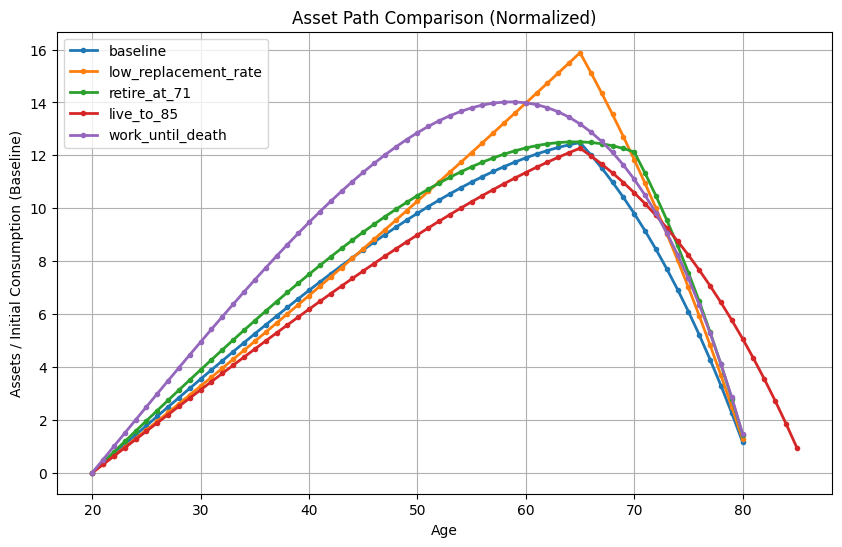

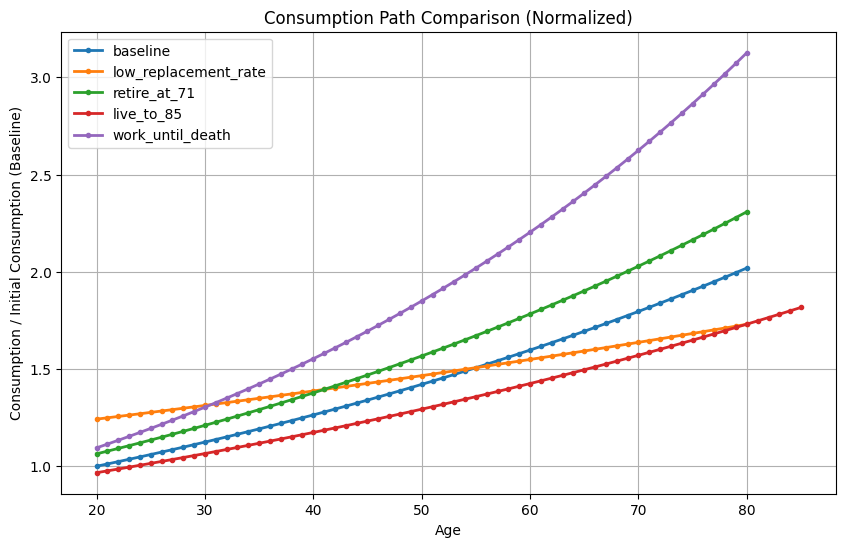

In [8]:
# 全シナリオの比較プロット（初期消費で正規化）

# 資産パスの比較
plt.figure("Assets - all scenarios", figsize=(10, 6))
for name, result in scenarios.items():
    age_axis = np.arange(20, 20 + len(result.equilibrium.aprime_path))
    plt.plot(age_axis, result.equilibrium.aprime_path / c1_baseline, 
             label=name, linewidth=2, marker='o', markersize=3)
plt.xlabel("Age")
plt.ylabel("Assets / Initial Consumption (Baseline)")
plt.title("Asset Path Comparison (Normalized)")
plt.legend()
plt.grid(True)
plt.show()

# 消費パスの比較
plt.figure("Consumption - all scenarios", figsize=(10, 6))
for name, result in scenarios.items():
    age_axis = np.arange(20, 20 + len(result.equilibrium.c_path))
    plt.plot(age_axis, result.equilibrium.c_path / c1_baseline, 
             label=name, linewidth=2, marker='o', markersize=3)
plt.xlabel("Age")
plt.ylabel("Consumption / Initial Consumption (Baseline)")
plt.title("Consumption Path Comparison (Normalized)")
plt.legend()
plt.grid(True)
plt.show()